# RK4 metodoaren trunkatze-errorearen analisia

Notebook honetan Runge-Kutta 4 (RK4) metodoaren trunkatze-errorea aztertuko da. Helburua da integrazio-pausoa ($h$) aldatuz errorea nola aldatzen den ikustea eta teorikoki espero den $O(h^4)$ portaera betetzen den egiaztatzea.

Horretarako, `m_out` parametroa (irteera bakoitzeko pauso kopurua) aldatuko dugu: 1, 2, 4, 8... Balio honek $h$ txikitzea dakar ($h \propto 1/m$).

### 1. Beharrezko Paketeak eta SPICE Kernelak

Lehenik eta behin, simulaziorako beharrezkoak diren Julia paketeak kargatzen dira (`LittleEphemeris`, `Plots`, `LinearAlgebra`, etab.).

Bestalde, NASAren SPICE sistema erabiltzen da planeten eta ilargiaren efemeride zehatzak kudeatzeko. Horretarako, bi kernel kargatzen dira:
*   `naif0012.tls`: Segundo interkalarren informazioa (denbora kudeatzeko).
*   `de440.bsp`: Planeta nagusien eta ilargiaren posizio datuak (efemerideak).

In [1]:
using Revise
using Pkg;Pkg.activate("..") 
# 3. Orain kargatu pakete guztiak
using GravitationSimulation

  Activating project at `~/Documentos/Ingenieritza_Informatikoa/GRaL/GrAL_github`
[ Info: Precompiling GravitationSimulation [922d4e26-8c19-4a49-933e-ea5f3b61e749]


In [2]:
using LittleEphemeris
using JSON
using CSV
using SPICE
using DataFrames
using FFTW
using Plots
using BenchmarkTools
using LinearAlgebra

In [3]:
# Karga nukleoak
furnsh("./data/naif0012.tls", "./data/de440.bsp")

### 2. Efemerideen Interpolazio Koefizienteen Sorkuntza

Atal honetan, Eguzki Sistemako gorputz nagusi guztien posizioak prestatzen dira. `LittleEphemeris` paketeak SPICE kernelak irakurtzen ditu eta Chebyshev polinomioen bidez hurbiltzen ditu gorputzen ibilbideak. Honek simulazioan zehar planeten posizioak oso azkar kalkulatzea ahalbidetzen du.

Kargatzen diren gorputzak:
*   Planetak: Merkurio, Artizarra, Lurra, Marte, Jupiter, Saturno, Urano, Neptuno.
*   Besteak: Eguzkia eta Ilargia.

Denbora tartea 2029ko urtarrilera mugatzen da.

In [4]:
# Gorputzen koefizienteak kargatu
# 3: Earth-Moon Barycenter, 5: Jupiter Barycenter, 10: Sun, 301: Moon
# 1: Mercury, 2: Venus, 4: Mars, 6: Saturn, 7: Uranus, 8: Neptune
ID_list = [1, 2, 3, 4, 5, 6, 7, 8, 10, 301]

# Denbora tartea zehatza (apophis_pos.txt fitxategiarekin bat egiteko)
# Assisten simulazioaren hasiera (2029ko urtarrilaren 1a) eta bukaera (2030eko urtarrilaren 1a)
et_0 = 10593.535998938605 * 86400
#et_end = 10958.037242609542 * 86400
et_end = et_0 + 50*86400
time_interval = (et_0, et_end)
time_interval_list = fill(time_interval, length(ID_list))

# Koefizienteak sortu (denbora tarte osorako)
create_coeffs_file("./data/coeffs.json", "./data/coeffs.csv", ID_list, time_interval_list)

Mercury = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 1, time_interval);
Venus   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 2, time_interval);
Earth   = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 3, time_interval);
Mars    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 4, time_interval);
Jupiter = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 5, time_interval);
Saturn  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 6, time_interval);
Uranus  = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 7, time_interval);
Neptune = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 8, time_interval);
Sun     = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 10, time_interval);
Moon    = BodyCoeffs("data/coeffs.json", "data/coeffs.csv", 301, time_interval);

### 3. Eredu Dinamikoa eta Integratzailea

Hemen definitzen dira simulazioaren bi zutabe nagusiak:

1.  **`f_all(u, p, t)`**: Higidura ekuazioak definitzen dituen funtzioa.
    *   Sarrerak: `u` (Apophisen egoera: posizioa eta abiadura), `p` (parametroak: masak), `t` (denbora).
    *   Prozesua: Une bakoitzean gorputz guztien (planetak, Eguzkia, Ilargia) posizioa kalkulatzen du eta, Newtonen grabitazio legea erabiliz, Apophisen gaineko azelerazio totala lortzen du.
    *   Irteera: Deribatuen bektorea (abiadura eta azelerazioa).

2.  **`RK4(...)`**: Runge-Kutta 4. ordenako zenbakizko integratzailea.
    *   Ekuazio diferentzialak ($du/dt = f(u,t)$) ebazten ditu denboran aurrera eginez pauso diskretuetan ($h$).
    *   Lau ebaluazio egiten ditu pauso bakoitzeko, errorea $O(h^5)$ ordenakoa izateko pauso bakoitzean (eta $O(h^4)$ globala).

### 4. Hasierako Baldintzak eta Parametro Fisikoak

Simulazioa hasteko beharrezkoak diren balioak ezartzen dira:

*   **Hasierako Egoera ($u_0$)**: Apophisen posizioa eta abiadura 2029ko hasieran. Datu hauek heliozentrikoetatik barizentrikoetara egokitzen dira eta unitateak bihurtzen dira (Unitate Astronomikoetatik/Egunetatik $\to$ Kilometroetara/Segundotara).
*   **Grabitazio Parametroak ($\mu$)**: Gorputz bakoitzaren masa bider grabitazio konstantea ($GM$). Balio hauek ezinbestekoak dira indar grabitatorioa kalkulatzeko.
*   **Integrazio Parametroak**: Integrazio totalaren iraupena (`dt_total`) eta laginketa tartea zehazten dira.

In [9]:
# Hasierako balioak eta konstanteak
u0 = [-5.5946538550488512E-01, 8.5647564757574512E-01, 3.0415066217102493E-01,
      -1.3818324735921638E-02, -6.0088275597939191E-03, -2.5805044631309632E-03]

# Heliozentrikotik barizentrikora
eguzkia_pos_barizentrikoa = [0.001232781221250307, -0.0012750764430978325, -0.0005187131180711941]
u0[1:3] += eguzkia_pos_barizentrikoa

# Unit conversion
AU = 149597870.7
DAY = 86400.0
u0[1:3] *= AU
u0[4:6] *= (AU / DAY)

# Grabitazio parametroak (km^3/s^2)
mu_S = 1.32712440042e11
mu_E = 398600.435
mu_M = 4902.80
mu_Mer = 22032.09
mu_V = 324858.59
mu_Ma = 42828.37
mu_J = 1.26686534e8
mu_Sat = 3.7931187e7
mu_U = 5.793939e6
mu_N = 6.836529e6

p_all = [mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N]
# Lehen agian p_all = [mu1, mu2, ...] zenuen. 
# Orain egitura hau behar du:
p_all = (
    mus = [mu_S, mu_E, mu_M, mu_Mer, mu_V, mu_Ma, mu_J, mu_Sat, mu_U, mu_N], # mu-en zerrenda
    bodies = [
        Sun, Earth, Moon, Mercury,
        Venus, Mars, Jupiter, Saturn, Uranus, Neptune] # posizioen zerrenda
)

t_0 = et_0
t_end = et_end

N_samples = 1000
dt_total = t_end - t_0
dt_out = dt_total / (N_samples - 1)

println("Simulazio parametroak:")
println("Hasiera (ET): $t_0")
println("Bukaera (ET): $t_end")
println("Lagin kopurua (Nomatua): $N_samples")
println("Irteera pausoa (dt_out): $dt_out s (~$(round(dt_out/3600, digits=2)) ordu)")

Simulazio parametroak:
Hasiera (ET): 9.152815103082955e8
Bukaera (ET): 9.196015103082955e8
Lagin kopurua (Nomatua): 1000
Irteera pausoa (dt_out): 4324.324324324324 s (~1.2 ordu)


### 5. Trunkatze Errorearen Analisia (Self-Consistency Test)

Atal honetan RK4 integratzailearen zehaztasuna aztertuko dugu **Self-Consistency (Auto-Konsistentzia)** test baten bidez.
Metodo honek simulazioaren emaitzak ez ditu kanpoko erreferentzia batekin alderatzen (ASSIST, JPL...), baizik eta **berezko erreferentzia zehatzago batekin**.

Prozedura:
1.  **Erreferentzia Sortu**: Simulazioa pauso oso txiki batekin exekutatzen da ($h_{ref} = dt_{out} / 64$). Trunkatze errorea $O(h^4)$ denez, soluzio hau "zehatza" dela onartuko dugu konparaziorako.
2.  **Probak Exekutatu**: Simulazio bera errepikatzen da hainbat pauso tamainarekin ($h = dt_{out} / 1, 2, 4...$).
3.  **Errorea Kalkulatu**: Proba bakoitzaren emaitza erreferentziarekin konparatzen da. Fisika berdina denez, ikusten den errore bakarra integratzailearen trunkatze errorea da.

Hemen bai, espero dugu malda **4** izatea (Log-Log grafikoan).

In [10]:
println("Erreferentziazko soluzioa (uu_ref) kalkulatzen...")

# m altu bat erabili (adibidez 64), hau izango da gure "egia"
m_ref = 64 
h_ref = dt_out / m_ref

# Kontuz: p_all-ek egitura berria (mus, bodies) izan behar du hemen ere!
tt_ref, uu_ref = RK4(u0, t_0, t_end, h_ref, p_all, f_all!, m_ref)

println("Eginda! Orain testa exekutatu dezakezu.")

Erreferentziazko soluzioa (uu_ref) kalkulatzen...
Eginda! Orain testa exekutatu dezakezu.


In [11]:
m_test_values = [1, 2, 4, 8, 16]
h_test = []
err_test = []

for m in m_test_values
    h = dt_out / m
    # GARRANTZITSUA: Ziurtatu p_all orain (mus=..., bodies=...) egitura duela
    tt, uu = RK4(u0, t_0, t_end, h, p_all, f_all!, m)

    err = 0.0
    # Erreferentziazko soluzioaren eta unekoaren arteko indizeak sinkronizatu behar dira
    # uu_ref-ek m_high pauso ditu irteera bakoitzeko, uu-k m pauso.
    # RK4-k m pauso bakoitzeko puntu bat gordetzen badu, tt-ren luzera bera izango dute.
    
    n = length(tt)
    for i in 1:n
        # Distantziaren errore erlatiboa kalkulatu
        # Erreferentzia (uu_ref) eta uneko soluzioa (uu) konparatzen ditugu
        diff = uu[i][1:3] - uu_ref[i][1:3]
        err_inst = norm(diff) / norm(uu_ref[i][1:3])
        
        # Errore maximoa gordetzen dugu (edo err_inst azken puntuan)
        err = max(err, err_inst)
    end
    
    push!(h_test, h)
    push!(err_test, err)
    
    println("m=$m, h=$h, Errore Erlatiboa Max: $err")
end

m=1, h=4324.324324324324, Errore Erlatiboa Max: 2.765714308810831e-9
m=2, h=2162.162162162162, Errore Erlatiboa Max: 1.750143921221371e-10
m=4, h=1081.081081081081, Errore Erlatiboa Max: 1.1245933534660005e-11
m=8, h=540.5405405405405, Errore Erlatiboa Max: 8.631700402321041e-13
m=16, h=270.27027027027026, Errore Erlatiboa Max: 3.6418358295744605e-13


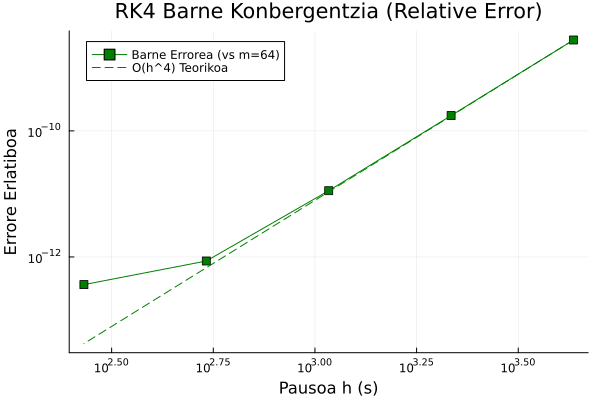

In [12]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:green)

# O(h^4) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^4)
ref_line2 = [C2 * h^4 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^4) Teorikoa")

### 6. Efemerideen zarata eta Sinkronizazioa

Aurreko grafikoan ikus daitekeenez, $h$ pausoa txikitzean errorea txikitzen da, teorikoki $O(h^4)$ espero den bezala. Hala ere, balio oso txikietan, portaera irregularra edo "zoru" bat ager daiteke.

Hau gertatzen da efemerideak (planeten posizioak) ez direlako funtzio analitiko perfektuak, baizik eta **zatika definitutako polinomioak** (Chebyshev). 
*   Integrazio pausoak ($h$) polinomio horien "jostura" edo mugak zeharkatzen baditu, errore txikiak sortzen dira interpolazioan.
*   Errore hauek integratzailearen errorearen gainetik jarri daitezke doitasun handian.

Arazo hau minimizatzeko, **denborazko sinkronizazioa** erabiliko dugu hurrengo ataletan: gure integrazio pausoa ($h$) doitu egingo dugu, efemerideen polinomio-luzeraren (`L_MOON`) zatitzaile zehatza izan dadin.

In [13]:
# ==========================================================
# 1. SINKRONIZAZIO OROKORRA (GAKOA)
# ==========================================================
# Ilargiaren polinomio baten iraupena (segundotan)
L_MOON = 345600.0  

# Jatorrizko dt_out nominala (fitxategiaren araberakoa)
# dt_nominala = dt_out 
dt_nominala = dt_out 

# Kalkulatu dt_out "perfektua": L_MOON-en dibisore zehatza dena.
# Honek bermatzen du irteera-puntuak nodoetan erortzea.
n_puntu_polinomioko = round(Int, L_MOON / dt_nominala) 
dt_out_sinkro = L_MOON / n_puntu_polinomioko

println("SINKRONIZAZIO DATUAK:")
println("- dt_out berria: $dt_out_sinkro s")
println("- Polinomio bakoitzeko irteera puntu kopurua: $n_puntu_polinomioko")

SINKRONIZAZIO DATUAK:
- dt_out berria: 43200.0 s
- Polinomio bakoitzeko irteera puntu kopurua: 8


In [14]:
# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=128 edo m=64)
# ==========================================================
# GARRANTZITSUA: Erreferentzia dt_out_sinkro berri honekin kalkulatu behar da.
# m_ref handiagoa izatea hobea da trunkatze-errorea garbi ikusteko.
m_ref = 32
h_ref = dt_out_sinkro / m_ref

# RK4-k m_ref pauso emango ditu irteera-puntu bakoitzeko
tt_ref, uu_ref = RK4(u0, t_0, et_end, h_ref, p_all, f_all!, m_ref)
println("\nErreferentzia internoa kalkulatuta (m=$m_ref).")


Erreferentzia internoa kalkulatuta (m=32).


In [15]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [1,2, 4, 8, 16]
h_test_emaitzak = Float64[]
err_test_emaitzak = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    # GAKOA: h balioa dt_out_sinkro-ren dibisore zehatza da beti.
    # m * h = dt_out_sinkro denez, tt[end] eta tt_ref[end] ZEHAZKI BERBERAK izango dira.
    h = dt_out_sinkro / m
    
    # RK4 exekutatu.
    tt, uu = RK4(u0, t_0, et_end, h, p_all, f_all!, m)
    
    # Posizioak une berean daude orain, denbora-desfaserik gabe.
    err = 0.
    n = length(tt)
    for i in 1:n
        # Errore erlatiboa
        err_inst = norm(uu[i][1:3]-uu_ref[i][1:3]) / norm(uu_ref[i][1:3])
        err = max(err, err_inst)
    end
    
    push!(h_test_emaitzak, h)
    push!(err_test_emaitzak, err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errore Erlatiboa (t=end): $err")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak)
    log_E = log.(err_test_emaitzak)
    
    # Regresio lineala: log(E) = A + p*log(h)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (RK4): 4.0")
end


Barne testa exekutatzen...
m=1, h=43200.0 s, Errore Erlatiboa (t=end): 2.3326282359303324e-5
m=2, h=21600.0 s, Errore Erlatiboa (t=end): 1.5639805578138202e-6
m=4, h=10800.0 s, Errore Erlatiboa (t=end): 1.0391440812295219e-7
m=8, h=5400.0 s, Errore Erlatiboa (t=end): 6.66030889696233e-9
m=16, h=2700.0 s, Errore Erlatiboa (t=end): 3.9716408500180305e-10

ANALISI NUMERIKOA:
- Lortutako malda (p): 3.9559
- Teoria (RK4): 4.0


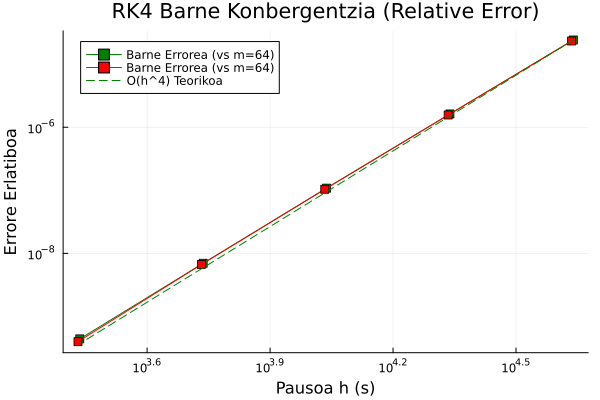

In [16]:
# Grafikoa
plot(h_test, err_test, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:green)
plot!(h_test_emaitzak, err_test_emaitzak, 
    xaxis=:log, yaxis=:log, 
    marker=:square, 
    label="Barne Errorea (vs m=64)", 
    xlabel="Pausoa h (s)", 
    ylabel="Errore Erlatiboa",
    title="RK4 Barne Konbergentzia (Relative Error)",
    legend=:topleft, color=:red)

# O(h^4) lerroa
# Lerroa pixka bat beherago jartzen dugu hobeto ikusteko
C2 = err_test[1] / (h_test[1]^4)
ref_line2 = [C2 * h^4 for h in h_test]
plot!(h_test, ref_line2, linestyle=:dash, color=:green, label="O(h^4) Teorikoa")

### 7. Polinomio-Nodoen Bateratzea (Sinkronizazio Osoa)

Aurreko pausoan `h` egokitu dugu polinomioaren luzerarekin ($L_{MOON}$), baina simulazioaren **hasiera puntua ($t_0$)** ausazkoa zen polinomioaren barruan. Honek esan nahi du oraindik mugak zeharkatu ditzakegula pausoaren erdian.

Sinkronizazio osoa lortzeko:
1.  Ilargiaren hurrengo polinomio-muga edo "nodoa" bilatu (`t_ilargiaren_nodo`).
2.  Apophisen egoera puntu horretaraino aurreratu.
3.  Simulazio nagusia **nodo horretatik bertatik** hasi.

Horrela, $h$ pausoa $L_{MOON}$-en zatitzailea denez, eta nodo batean hasten garenez, simulazioaren pauso guztiak polinomio berdinaren barruan edo muga zehatzetan eroriko dira, efemerideetako "zarata" ia guztiz ezabatuz.

In [17]:
#Ilargiaren gertueneko nodoa
t_ilargiaren_nodo = 0
for time in Moon.timeIntervals
    if time>t_0
        t_ilargiaren_nodo = time
        break
    end
end

#Apophisen datuak ilargiaren nodoan
m = 16
h = 100/m
u_nodo= RK4(u0, t_0, t_ilargiaren_nodo, h, p_all, f_all!, m)[2][end]

6-element Vector{Float64}:
   -8.753044972823687e7
    1.2611038283678381e8
    3.415934961041391e7
  -23.445247839936467
  -11.117239421923873
 -123.65465750977728

Behin Apophisen datuak une jakin horretan izanda, notoetatik pasata simulatu dezakegu ibilbidea.

In [18]:
# ==========================================================
# 2. ERREFERENTZIA INTERNOA (m=128 edo m=64)
# ==========================================================
# GARRANTZITSUA: Erreferentzia dt_out_sinkro berri honekin kalkulatu behar da.
# m_ref handiagoa izatea hobea da trunkatze-errorea garbi ikusteko.
m_ref = 32
h_ref = dt_out_sinkro / m_ref

# RK4-k m_ref pauso emango ditu irteera-puntu bakoitzeko
tt_ref, uu_ref = RK4(u_nodo, t_ilargiaren_nodo, et_end, h_ref, p_all, f_all!, m_ref)
println("\nErreferentzia internoa kalkulatuta (m=$m_ref).")


Erreferentzia internoa kalkulatuta (m=32).


In [19]:
# ==========================================================
# 3. ANALISI BEGIZTA (Auto-konsistentzia test garbia)
# ==========================================================
m_test_values = [1,2,4,8,16]
h_test_emaitzak_sink = Float64[]
err_test_emaitzak_sink = Float64[]

println("\nBarne testa exekutatzen...")

for m in m_test_values
    # GAKOA: h balioa dt_out_sinkro-ren dibisore zehatza da beti.
    # m * h = dt_out_sinkro denez, tt[end] eta tt_ref[end] ZEHAZKI BERBERAK izango dira.
    h = dt_out_sinkro / m
    
    # RK4 exekutatu.
    tt, uu = RK4(u_nodo, t_ilargiaren_nodo, et_end, h, p_all, f_all!, m)
    
    # Posizioak une berean daude orain, denbora-desfaserik gabe.
    err = 0.
    n = length(tt)
    for i in 1:n
        # Errore erlatiboa
        err_inst = norm(uu[i][1:3]-uu_ref[i][1:3]) / norm(uu_ref[i][1:3])
        err = max(err, err_inst)
    end
    
    push!(h_test_emaitzak_sink, h)
    push!(err_test_emaitzak_sink, err)
    
    println("m=$m, h=$(round(h, digits=4)) s, Errore Erlatiboa (t=end): $err")
end

# ==========================================================
# 4. MALDA (SLOPE) ETA KONBERGENTZIA
# ==========================================================
if length(h_test_emaitzak) > 1
    log_h = log.(h_test_emaitzak_sink)
    log_E = log.(err_test_emaitzak_sink)
    
    # Regresio lineala: log(E) = A + p*log(h)
    X = hcat(ones(length(log_h)), log_h)
    coeffs = X \ log_E
    
    println("\nANALISI NUMERIKOA:")
    println("- Lortutako malda (p): $(round(coeffs[2], digits=4))")
    println("- Teoria (RK4): 4.0")
end


Barne testa exekutatzen...
m=1, h=43200.0 s, Errore Erlatiboa (t=end): 2.2299666444137938e-5
m=2, h=21600.0 s, Errore Erlatiboa (t=end): 1.5051666899174455e-6
m=4, h=10800.0 s, Errore Erlatiboa (t=end): 9.995543229728939e-8
m=8, h=5400.0 s, Errore Erlatiboa (t=end): 6.405205009058535e-9
m=16, h=2700.0 s, Errore Erlatiboa (t=end): 3.819393862324054e-10

ANALISI NUMERIKOA:
- Lortutako malda (p): 3.9543
- Teoria (RK4): 4.0


### 8. Emaitzen Konparaketa eta Ondorioak

Beheko grafikoan hiru estrategien konparaketa ikusten da:

1.  🔴 **Jatorrizkoa (Gorria)**: Inolako sinkronizaziorik gabe. *Plateau* edo zoru bat ager daiteke doitasun handian, efemerideen interpolazio zarata dela eta.
2.  🟢 **Erdi-sinkronizatua (Berdea)**: Pausoa ($h$) sinkronizatua, baina hasiera puntua ($t_0$) ez. Hobekuntza egon daiteke, baina zarata hondarrak egon daitezke.
3.  🔵 **Sinkronizazio Osoa (Urdina)**: Nodoetatik hasita eta pauso sinkronizatuekin. Hemen RK4 metodoaren $O(h^4)$ portaera garbia ikusi beharko litzateke doitasun maila altuenetaraino.

Honek frogatzen du doitasun handiko simulazioetan garrantzitsua dela integratzailearen pausoak kanpo-datuen (efemerideen) egiturarekin bat egitea.

┌ Warning: Skipped marker arg triangle.
└ @ Plots ~/.julia/packages/Plots/bpxfB/src/args.jl:1155


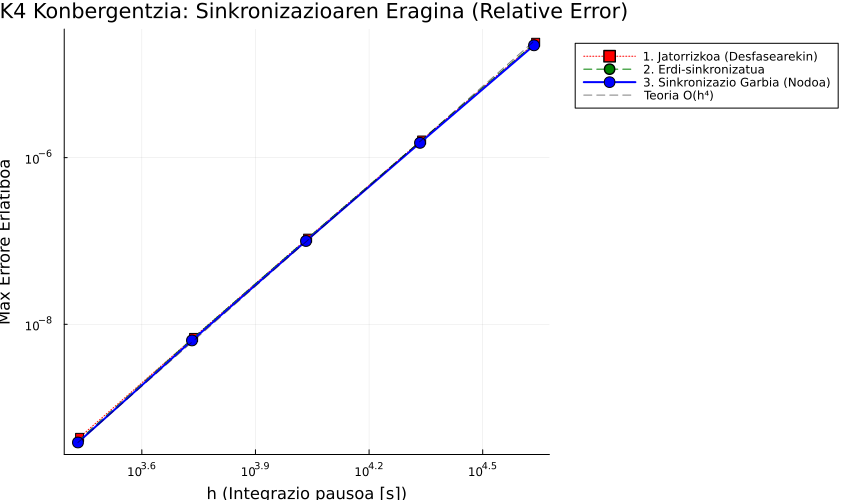

In [20]:
using Plots

# Grafikoaren hasieratzea
p_comp = plot(xaxis=:log, yaxis=:log, 
              xlabel="h (Integrazio pausoa [s])", 
              ylabel="Max Errore Erlatiboa",
              title="RK4 Konbergentzia: Sinkronizazioaren Eragina (Relative Error)",
              legend=:outertopright, 
              grid=true, 
              size=(850, 500))

# 1. Jatorrizko datuak (Sinkronizatu gabe, agian 'plateau' batekin)
plot!(p_comp, h_test, err_test, 
      marker=:square, color=:red, linestyle=:dot,
      label="1. Jatorrizkoa (Desfasearekin)")

# 2. Bigarren saiakera (err_test_emaitzak)
plot!(p_comp, h_test_emaitzak, err_test_emaitzak, 
      marker=:triangle, color=:green, linestyle=:dash,
      label="2. Erdi-sinkronizatua")

# 3. Azken bertsioa (Nodoarekin sinkronizatuta - GAKOA)
plot!(p_comp, h_test_emaitzak_sink, err_test_emaitzak_sink, 
      marker=:circle, markersize=6, color=:blue, linewidth=2,
      label="3. Sinkronizazio Garbia (Nodoa)")

# 4. Erreferentzia Teorikoa (p=4 malda) alderatzeko
h_min, h_max = minimum(h_test_emaitzak_sink), maximum(h_test_emaitzak_sink)
# Lerro teorikoa azken datuen gainean jartzeko konstantea
C_teorikoa = err_test_emaitzak_sink[end] / (h_test_emaitzak_sink[end]^4)
plot!(p_comp, [h_min, h_max], [C_teorikoa * h_min^4, C_teorikoa * h_max^4], 
      line=:dash, color=:black, alpha=0.5,
      label="Teoria O(h⁴)")

display(p_comp)